# 실습 6-2 : STUCCO (대조집합 학습)

#### **<실습 내용>**

1. 대조집합 학습 개요
- STUCCO 알고리즘 원리

2. STUCCO 기본 예제 (Process_Data)
- 데이터 전처리 (연속형 변수 범주화)
- 대조집합(cset) 도출 및 해석

3. Vibe Coding 실습 (통신사 고객 이탈 데이터)

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import logging
from stucco import ContrastSetLearner  # 대조집합 학습(Contrast Set Learning)을 수행하는 STUCCO 알고리즘 구현체

# OS별 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

logging.getLogger().setLevel(logging.WARNING)  # stucco.py의 상세 진행 로그 숨기기

---

## 1) 데이터 불러오기

In [2]:
data = pd.read_csv("dataset/day6-2_data.csv")
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (596, 12)


,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0


In [3]:
# 불량 기준 설정: 제품 1개당 불량 개수(Y)가 3개 이상이면 Fault, 아니면 Pass로 그룹 라벨 생성
data["Fail"] = ["Fault" if i >= 3 else "Pass" for i in data["Y"]]
data

,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y,Fail
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0,Pass
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0,Pass
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4,Fault
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0,Pass
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,1001592,15,E,A,C,D,115.153,31.652,A,A,C,0,Pass
592,1001593,15,E,A,B,D,114.593,33.890,A,A,B,0,Pass
593,1001594,20,U,A,A,B,105.724,33.251,B,B,A,0,Pass
594,1001595,25,E,A,A,A,109.783,32.054,A,A,D,0,Pass


In [4]:
print("클래스 분포:")
print(data["Fail"].value_counts())

클래스 분포:
Fail
Pass     471
Fault    125
Name: count, dtype: int64


**활용할 반도체 공정 데이터 소개 (6-1과 동일)**

| 변수 | 설명 |
|---|---|
| Prod_ID | 제품 고유 ID |
| M1 | 공정 설비 온도 설정값 (15/20/25/30) |
| M2 | 사용 설비 ID (E, U, K) |
| P1 ~ P6 | 제품 설계/공정 옵션 (범주형 파라미터) |
| C1, C2 | 공정 중 측정된 연속형 값 |
| Y | 제품 1개당 발생한 불량 개수 |
| Fail | Y >= 3이면 Fault, 아니면 Pass로 정의한 라벨 |

## 2) 전처리하기

> STUCCO는 입력변수로 **범주형 변수만** 허용하므로 연속형 변수(C1, C2)는 구간화하여 범주형 변수 처럼 나타내야함

In [5]:
# 1. M1
# 숫자(15/20/25/30)로 저장되어 있음
# 그러나 실제로는 '온도 설정값'을 의미하는 범주이므로 범주형으로 변환
data["M1"] = data["M1"].astype("object")

# 2. 연속형 변수 C1, C2
# qcut: 데이터 개수가 균등하도록 4구간으로 분할
data["C1_cut"] = pd.qcut(data["C1"], 4)
# cut: 의미 있는 경계값 기준으로 직접 3구간 지정
data["C2_cut"] = pd.cut(data["C2"], bins=[18, 28, 32, 39], labels=["Low", "Normal", "High"]) 

### 2-1) STUCCO 실행

1. 비교할 그룹 설정
2. Contrast Set 후보 규칙 생성
3. 유의미한 규칙 추출

In [6]:
# STUCCO에 불필요한 변수 제거
# (ID, 이미 구간화한 원본 연속형 변수, 라벨 만드는 데 쓴 Y)
contra_data = data.drop(["Prod_ID", "C1", "C2", "Y"], axis=1)
contra_data

,M1,M2,P1,P2,P3,P4,P5,P6,Fail,C1_cut,C2_cut
0,15,E,A,B,D,A,A,B,Pass,"(109.191, 112.225]",Low
1,20,E,A,B,D,A,A,A,Pass,"(109.191, 112.225]",Low
2,15,U,A,B,B,B,B,B,Fault,"(109.191, 112.225]",Low
3,25,K,B,B,C,A,A,C,Pass,"(106.365, 109.191]",Low
4,20,E,A,A,D,B,B,A,Pass,"(102.158, 106.365]",Normal
...,...,...,...,...,...,...,...,...,...,...,...
591,15,E,A,C,D,A,A,C,Pass,"(112.225, 123.34]",Normal
592,15,E,A,B,D,A,A,B,Pass,"(112.225, 123.34]",High
593,20,U,A,A,B,B,B,A,Pass,"(102.158, 106.365]",High
594,25,E,A,A,A,A,A,D,Pass,"(109.191, 112.225]",High


> 1. 비교할 그룹 설정 (ContrastSetLearner())

In [7]:
# ContrastSetLearner(DataFrame, group_feature)

# "Fail" 컬럼의 그룹을 기준으로 Contrast Set 탐색
# Contrast Set: 그룹 간 차이를 가장 잘 설명하는 규칙

learner = ContrastSetLearner(contra_data, group_feature="Fail")
learner

> 2. Contrast Set 후보 규칙 생성 (learn())

In [8]:
# learner.learn():
# 그룹 간 차이를 설명할 수 있는 규칙 후보(조건 조합)를 생성
# 각 규칙의 그룹별 등장 빈도를 계산

# max_length: 규칙을 구성하는 최대 조건 수
# n_matrices: 규칙이 각 그룹에서 몇 번 나타났는지 등의 빈도 정보를 저장

n_matrices = learner.learn(max_length=3)
n_matrices

4217

> 3. 유의미한 규칙 추출 (score())

In [9]:
# learner.score():
# learn( )에서 생성한 빈도 정보를 활용해 규칙별 Support, Confidence, Lift를 계산

# Support: 규칙의 출현 비율
# Confidence: 규칙이 나타났을 때 해당 그룹일 확률
# Lift: 특정 그룹과의 연관성 정도

# lift가 2.0 이상인(특정 그룹과의 연관성 정도) 규칙만 채택
contrast_rules = learner.score(min_lift=2.0)
contrast_rules

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fail=>Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fail=>Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fail=>Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fail=>Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fail=>Fault,2.300000
5,"(P1=>A, P6=>D, C1_cut=>(106.365, 109.191])",Fail=>Fault,2.258065
9,"(M2=>K, P1=>A, P2=>B)",Fail=>Fault,2.250000
10,"(P1=>A, P5=>B, C1_cut=>(112.225, 123.34])",Fail=>Fault,2.222222
8,"(P1=>A, P3=>D, P6=>D)",Fail=>Fault,2.181818
16,"(M1=>25, M2=>K, P1=>A)",Fail=>Fault,2.181818


In [10]:
# group 컬럼 값이 "Fail=>Fault", "Fail=>Pass" 형태로 저장되어 있음
# 보기 쉽게 "Fault", "Pass"만 남도록 문자열 변경
contrast_rules["group"] = contrast_rules["group"].str.replace("Fail=>", "")

# learn() 단계에서 생성된 전체 조건 조합(규칙 후보) 수 출력
print("생성된 조건 조합 수:", n_matrices)

# score() 단계의 기준을 통과하여 최종 선택된 Contrast Set 규칙 수 출력
print("도출된 규칙 수:", contrast_rules.shape[0])

생성된 조건 조합 수: 4217
도출된 규칙 수: 17


### 2-2) 결과 해석

In [11]:
# 도출된 규칙 확인
# 실제로는 Pass 규칙도 있었는데 score 기준에 따라 필터링 된 것임

contrast_rules.head()

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fault,2.300000


In [12]:
# Fault 그룹을 설명하는 규칙만 추출
fault_rules = contrast_rules.loc[contrast_rules["group"] == "Fault"]

# Lift 기준 상위 5개 규칙 확인
fault_rules.sort_values(by="lift", ascending=False).head()

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fault,2.300000


In [13]:
# Lift가 가장 높은 Contrast Set 규칙
# (P1=A) AND (P3=A) AND (C2_cut=High)를 만족하는 데이터 선택

cset_mask = (data["P1"] == "A") & (data["P3"] == "A") & (data["C2_cut"] == "High")

# 규칙을 만족하는 데이터의 불량(Fail) 분포 확인
print("cset 해당 데이터 불량 분포:")
print(data.loc[cset_mask, "Fail"].value_counts())
print()

# 규칙을 만족하지 않는 데이터의 불량(Fail) 분포 확인
print("cset 미해당 데이터 불량 분포:")
print(data.loc[~cset_mask, "Fail"].value_counts())

cset 해당 데이터 불량 분포:
Fail
Fault    12
Pass      6
Name: count, dtype: int64

cset 미해당 데이터 불량 분포:
Fail
Pass     465
Fault    113
Name: count, dtype: int64


---

## 3) Vibe Coding 실습 (통신사 고객 이탈 데이터)

STUCCO를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 직접 적용해 봅니다.

- `dataset/day6_vibecoding.csv` 파일 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

In [15]:
# 필요한 라이브러리 호출하기
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# 0. 데이터 불러오기
data = pd.read_csv('dataset/day6_vibecoding.csv')

# 1. 결측치 처리
# 범주형(InternetService, PaymentMethod) → 최빈값 대치
for col in ['InternetService', 'PaymentMethod']:
    data[col] = data[col].fillna(data[col].mode()[0])

# TotalCharges → 중앙값 대치
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# tenure, MonthlyCharges → KNN Imputer (비슷한 고객들의 값을 참고해 대치)
knn_cols = ['tenure', 'MonthlyCharges']
imputer = KNNImputer(n_neighbors=5)
data[knn_cols] = imputer.fit_transform(data[knn_cols])

# 2. 군집화에 쓰지 않을 컬럼 분리 
# Churn: 군집화 단계에서는 사용하지 않고, 군집 해석(군집별 이탈률 비교) 시에만 참고
churn = data['Churn']
X = data.drop(columns=['Churn'])

# 3. 수치형 변수 스케일링 
# K-Means/DBSCAN은 거리 기반이라 변수 스케일이 다르면 특정 변수가 거리 계산을 왜곡할 수 있음
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# 4. 범주형 변수 인코딩 
# 값이 2개뿐인 이진 범주형 변수는 0/1로 Label Encoding
binary_map = {
    'gender':           {'Male': 1, 'Female': 0},
    'Partner':          {'Yes': 1, 'No': 0},
    'Dependents':       {'Yes': 1, 'No': 0},
    'PhoneService':     {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    X[col] = X[col].map(mapping)

# 값이 3개 이상인 다중 범주형 변수는 One-Hot Encoding
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.286412,0,1,-1.173697,-0.994242,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.069187,1,0,-0.265601,-0.173244,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.245333,1,1,-0.369479,-0.959674,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.521054,0,0,-0.756509,-0.194766,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.245333,1,1,0.195149,-0.940470,False,...,False,False,False,False,False,False,False,False,True,False


**[과제]** 본 데이터셋에서의 연속형 범수인 'tenure', 'MonthlyCharges', 'TotalCharges'를 `pd.qcut` 등으로 구간화하고 `ContrastSetLearner`로 Churn(Yes/No) 그룹 간 대조집합을 도출하는 코드를 AI와 상의해서 작성하세요.

In [16]:
# STUCCO용 데이터 준비 (Churn Yes/No 그룹 간 대조집합 학습)
from sklearn.impute import KNNImputer

churn_data = pd.read_csv("dataset/day6_vibecoding.csv")

# 결측치 처리
for col in ["InternetService", "PaymentMethod"]:
    churn_data[col] = churn_data[col].fillna(churn_data[col].mode()[0])

churn_data["TotalCharges"] = pd.to_numeric(churn_data["TotalCharges"], errors="coerce")
churn_data["TotalCharges"] = churn_data["TotalCharges"].fillna(churn_data["TotalCharges"].median())

knn_cols = ["tenure", "MonthlyCharges"]
imputer = KNNImputer(n_neighbors=5)
churn_data[knn_cols] = imputer.fit_transform(churn_data[knn_cols])

# STUCCO는 범주형 변수만 허용 → 연속형 3개를 qcut으로 4구간 범주화
churn_data["tenure_cut"] = pd.qcut(churn_data["tenure"], 4, duplicates="drop")
churn_data["MonthlyCharges_cut"] = pd.qcut(churn_data["MonthlyCharges"], 4, duplicates="drop")
churn_data["TotalCharges_cut"] = pd.qcut(churn_data["TotalCharges"], 4, duplicates="drop")

# 구간화한 원본 연속형 변수는 제거
contra_churn = churn_data.drop(["tenure", "MonthlyCharges", "TotalCharges"], axis=1)

# 숫자형 이진 변수도 범주로 취급
contra_churn["SeniorCitizen"] = contra_churn["SeniorCitizen"].astype("object")

print("클래스 분포:")
print(contra_churn["Churn"].value_counts())
print()

# 1. 비교 그룹 설정
learner_churn = ContrastSetLearner(contra_churn, group_feature="Churn")

# 2. Contrast Set 후보 규칙 생성
n_matrices_churn = learner_churn.learn(max_length=3)

# 3. 유의미한 규칙 추출 (lift >= 2.0)
contrast_rules_churn = learner_churn.score(min_lift=2.0)
contrast_rules_churn["group"] = contrast_rules_churn["group"].str.replace("Churn=>", "")

print("생성된 조건 조합 수:", n_matrices_churn)
print("도출된 규칙 수:", contrast_rules_churn.shape[0])
contrast_rules_churn

클래스 분포:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

생성된 조건 조합 수: 20259
도출된 규칙 수: 325


,rule,group,lift
256,"(InternetService=>Fiber optic, PaymentMethod=>...",Yes,4.626094
141,"(StreamingMovies=>Yes, Contract=>Month-to-mont...",Yes,4.572431
294,"(MultipleLines=>Yes, InternetService=>Fiber op...",Yes,4.555861
259,"(InternetService=>Fiber optic, MonthlyCharges_...",Yes,4.492769
122,"(StreamingTV=>Yes, Contract=>Month-to-month, t...",Yes,4.467431
...,...,...,...
129,"(Partner=>No, OnlineSecurity=>No, StreamingMov...",Yes,2.007262
293,"(MultipleLines=>Yes, InternetService=>Fiber op...",Yes,2.006769
44,"(OnlineBackup=>No, StreamingMovies=>No, Contra...",Yes,2.006207
218,"(InternetService=>Fiber optic, StreamingTV=>No...",Yes,2.002480


**[과제]** 도출된 규칙 중 이탈(Yes) 그룹에서 lift가 높은 상위 규칙들을 확인하고 어떤 조건 조합이 이탈과 강하게 연관되는지 AI와 함께 해석해 보세요.

In [17]:
def parse_rule_conditions(rule):
    """STUCCO rule(tuple/문자열) → [(변수, 값), ...] 리스트로 변환"""
    if isinstance(rule, tuple):
        conditions = rule
    else:
        conditions = str(rule).strip("()").split(", ")
    return [cond.split("=>", 1) for cond in conditions]


# 이탈(Yes) 그룹을 설명하는 규칙만 추출
yes_rules = contrast_rules_churn.loc[contrast_rules_churn["group"] == "Yes"].copy()

# Lift 기준 상위 10개 규칙
top_n = 10
top_yes_rules = yes_rules.sort_values(by="lift", ascending=False).head(top_n)
print("=== 이탈(Yes) 그룹 Lift 상위 10개 규칙 ===")
display(top_yes_rules)

# ── 공통 패턴 분석 (상위 10개 규칙 기준) ──
var_counts, val_counts = {}, {}
for rule in top_yes_rules["rule"]:
    for var, val in parse_rule_conditions(rule):
        var_counts[var] = var_counts.get(var, 0) + 1
        val_counts[f"{var} => {val}"] = val_counts.get(f"{var} => {val}", 0) + 1

print(f"\n=== 상위 {top_n}개 규칙에서 자주 등장하는 변수 (Top 10) ===")
var_freq = pd.Series(var_counts).sort_values(ascending=False)
for var, cnt in var_freq.head(10).items():
    print(f"  {var:25s}  {cnt}/{top_n}회 ({cnt/top_n:.0%})")

print(f"\n=== 상위 {top_n}개 규칙에서 자주 등장하는 조건 (Top 15) ===")
val_freq = pd.Series(val_counts).sort_values(ascending=False)
for cond, cnt in val_freq.head(15).items():
    print(f"  {cond:55s}  {cnt}/{top_n}회")

# 변수별 등장 빈도 시각화
fig, ax = plt.subplots(figsize=(8, 4))
var_freq.head(8).sort_values().plot(kind="barh", ax=ax, color="tomato")
ax.set_xlabel(f"상위 {top_n}개 규칙 내 등장 횟수")
ax.set_title("이탈(Yes) 규칙에 반복 등장하는 변수")
plt.tight_layout()
plt.show()

=== 이탈(Yes) 그룹 Lift 상위 10개 규칙 ===


,rule,group,lift
256,"(InternetService=>Fiber optic, PaymentMethod=>...",Yes,4.626094
141,"(StreamingMovies=>Yes, Contract=>Month-to-mont...",Yes,4.572431
294,"(MultipleLines=>Yes, InternetService=>Fiber op...",Yes,4.555861
259,"(InternetService=>Fiber optic, MonthlyCharges_...",Yes,4.492769
122,"(StreamingTV=>Yes, Contract=>Month-to-month, t...",Yes,4.467431
308,"(SeniorCitizen=>1, StreamingMovies=>Yes, Contr...",Yes,4.329400
271,"(DeviceProtection=>No, Contract=>Month-to-mont...",Yes,4.192222
247,"(PaperlessBilling=>Yes, MonthlyCharges_cut=>(7...",Yes,4.164657
270,"(OnlineBackup=>No, Contract=>Month-to-month, M...",Yes,4.039326
285,"(MultipleLines=>Yes, Contract=>Month-to-month,...",Yes,4.012019


### 이탈(Yes) 공통 패턴 해석

상위 10개 STUCCO 규칙을 종합하면, 이탈 고객은 아래 **5가지 패턴**이 반복적으로 나타납니다.

| 패턴 | 대표 조건 | 해석 |
|---|---|---|
| **1. 무약정 고객** | `Contract => Month-to-month` | 약정이 없어 이탈 비용이 낮음. 상위 규칙 대부분에 포함 |
| **2. 광섬유 + 고요금** | `InternetService => Fiber optic`, `MonthlyCharges_cut` 상위 구간 | 고속 인터넷(광섬유) 고가 상품 이용 고객의 이탈 위험 |
| **3. 불리한 결제 수단** | `PaymentMethod => Electronic check` | 자동이체/카드 대비 전자수표 결제 고객의 이탈 연관성 높음 |
| **4. 단기·저누적 고객** | `tenure_cut` / `TotalCharges_cut` 하위 구간 | 가입 기간 짧고 누적 요금 낮음 → 아직 충성도가 형성되지 않음 |
| **5. 부가서비스 미가입** | `OnlineSecurity/TechSupport/DeviceProtection => No` | 보안·기술지원 등 부가서비스 없이 기본 요금제만 사용 |

**한 줄 요약**

> 이탈 위험이 높은 고객 프로필 = **무약정 + 광섬유/고요금 + 전자수표 결제 + 단기 가입 + 부가서비스 미가입**

**마케팅 시사점**
- 무약정 광섬유 고객 → 장기 약정 전환 프로모션
- 전자수표 결제 고객 → 자동이체/카드 결제 전환 유도
- 신규·단기 고객 → 온보딩 기간 집중 관리 (가입 1년 이내)

**[과제]** 가장 중요한 규칙에 해당하는 고객들의 실제 이탈률을 비교해서 해당 규칙이 실제로 유의미한지 검증해 보세요.

최상위 규칙: ('InternetService=>Fiber optic', 'PaymentMethod=>Electronic check', 'TotalCharges_cut=>(18.799, 402.225]')
Lift: 4.63

전체 이탈률: 26.54%

[규칙 해당 고객] Churn 분포:
Churn
Yes    299
No      95
Name: count, dtype: int64
이탈률: 75.89%

[규칙 미해당 고객] Churn 분포:
Churn
No     5079
Yes    1570
Name: count, dtype: int64
이탈률: 23.61%


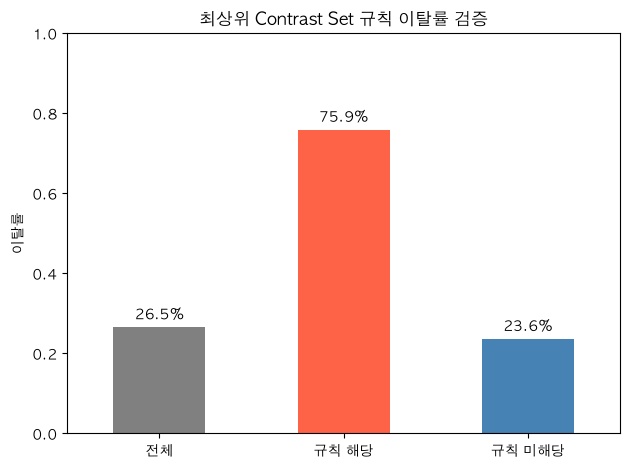

In [19]:
def rule_to_mask(df, rule):
    """STUCCO 규칙을 boolean mask로 변환 (rule은 tuple 또는 문자열)"""
    if isinstance(rule, tuple):
        conditions = rule
    else:
        conditions = str(rule).strip("()").split(", ")

    mask = pd.Series(True, index=df.index)
    for cond in conditions:
        var, val = cond.split("=>", 1)
        mask &= df[var].astype(str) == val
    return mask


# Lift가 가장 높은 규칙 선택
top_rule = yes_rules.sort_values(by="lift", ascending=False).iloc[0]
print("최상위 규칙:", top_rule["rule"])
print(f"Lift: {top_rule['lift']:.2f}")
print()

cset_mask = rule_to_mask(churn_data, top_rule["rule"])
overall_rate = (churn_data["Churn"] == "Yes").mean()

print("전체 이탈률:", f"{overall_rate:.2%}")
print()

print("[규칙 해당 고객] Churn 분포:")
print(churn_data.loc[cset_mask, "Churn"].value_counts())
cset_rate = (churn_data.loc[cset_mask, "Churn"] == "Yes").mean()
print(f"이탈률: {cset_rate:.2%}")
print()

print("[규칙 미해당 고객] Churn 분포:")
print(churn_data.loc[~cset_mask, "Churn"].value_counts())
non_cset_rate = (churn_data.loc[~cset_mask, "Churn"] == "Yes").mean()
print(f"이탈률: {non_cset_rate:.2%}")

# 시각화: 전체 vs 규칙 해당/미해당 이탈률 비교
compare = pd.Series({
    "전체": overall_rate,
    "규칙 해당": cset_rate,
    "규칙 미해당": non_cset_rate,
})
compare.plot(kind="bar", color=["gray", "tomato", "steelblue"], rot=0)
plt.ylabel("이탈률")
plt.title("최상위 Contrast Set 규칙 이탈률 검증")
plt.ylim(0, 1)
for i, v in enumerate(compare):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()